In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("processed", exist_ok=True)

df_clientes = pd.read_csv('/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/clientes.csv')
df_churn = pd.read_csv('data/raw/churn_target.csv')


In [114]:
print(df_clientes.shape)
print(df_churn.shape)

df_clientes.info()
df_churn.info()

df_clientes.head()
df_churn.head()

(10150, 14)
(321987, 3)
<class 'pandas.DataFrame'>
RangeIndex: 10150 entries, 0 to 10149
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        10150 non-null  str    
 1   zona_id           10150 non-null  str    
 2   region            10150 non-null  str    
 3   tipo_zona         10150 non-null  str    
 4   poblacion_zona    10150 non-null  int64  
 5   edad              9845 non-null   float64
 6   sexo              10105 non-null  str    
 7   estado_civil      10071 non-null  str    
 8   num_lineas        10150 non-null  int64  
 9   tipo_plan         10150 non-null  str    
 10  tipo_dispositivo  10150 non-null  str    
 11  ingreso_estimado  9846 non-null   float64
 12  antiguedad_meses  9845 non-null   float64
 13  descuento_activo  10150 non-null  int64  
dtypes: float64(3), int64(3), str(8)
memory usage: 1.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 321987 entries, 0 to 321986
D

,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


In [115]:
df_clientes = df_clientes.drop_duplicates(subset="cliente_id")

In [116]:
churn_cliente = df_churn.groupby("cliente_id")["churn"].max().reset_index()

In [117]:
df_clientes = df_clientes.merge(churn_cliente, on="cliente_id", how="left")

In [118]:
df_clientes.isnull().sum()

cliente_id            0
zona_id               0
region                0
tipo_zona             0
poblacion_zona        0
edad                300
sexo                 45
estado_civil         77
num_lineas            0
tipo_plan             0
tipo_dispositivo      0
ingreso_estimado    300
antiguedad_meses    300
descuento_activo      0
churn                 0
dtype: int64

In [119]:
df_clientes["antiguedad_meses"] = df_clientes["antiguedad_meses"].fillna(df_clientes["antiguedad_meses"].mean())

In [120]:
df_clientes["edad"] = df_clientes["edad"].fillna(df_clientes["edad"].mean())
df_clientes["ingreso_estimado"] = df_clientes["ingreso_estimado"].fillna(df_clientes["ingreso_estimado"].mean())
df_clientes["antiguedad_meses"] = df_clientes["antiguedad_meses"].fillna(df_clientes["antiguedad_meses"].mean())

In [121]:
df_clientes["sexo"] = df_clientes["sexo"].fillna(df_clientes["sexo"].mode()[0])
df_clientes["estado_civil"] = df_clientes["estado_civil"].fillna(df_clientes["estado_civil"].mode()[0])

In [122]:
df_clientes.loc[df_clientes["antiguedad_meses"] < 0, "antiguedad_meses"] = None

In [123]:
df_clientes["antiguedad_meses"] = df_clientes["antiguedad_meses"].fillna(
    df_clientes["antiguedad_meses"].median()
)

In [124]:
df_clientes["churn"].value_counts(normalize=True)

churn
0    0.8
1    0.2
Name: proportion, dtype: float64

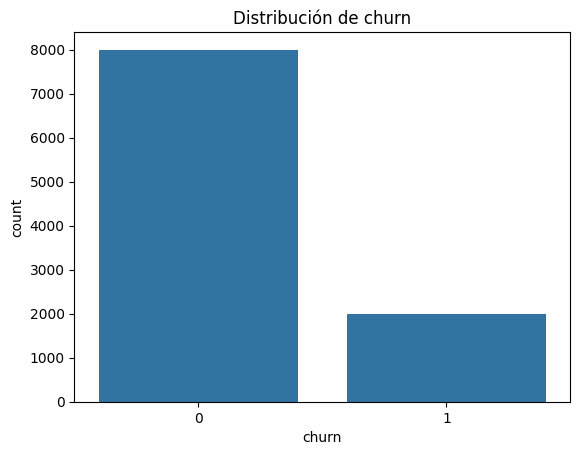

In [125]:
sns.countplot(data=df_clientes, x="churn")
plt.title("Distribución de churn")
plt.show()

In [126]:
df_clientes.groupby("churn")["antiguedad_meses"].mean()

churn
0    34.703981
1    28.590261
Name: antiguedad_meses, dtype: float64

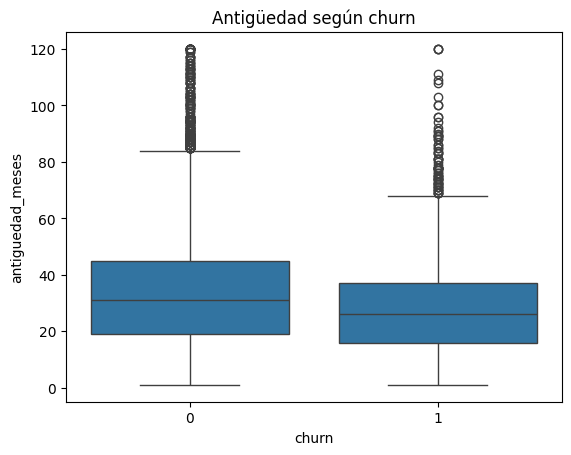

In [127]:
sns.boxplot(data=df_clientes, x="churn", y="antiguedad_meses")
plt.title("Antigüedad según churn")
plt.show()

Los clientes con menor antigüedad presentan mayor churn.

In [128]:
df_clientes.groupby("tipo_plan")["churn"].mean().sort_values(ascending=False)

tipo_plan
Prepago     0.262313
Contrato    0.214349
Premium     0.160608
Name: churn, dtype: float64

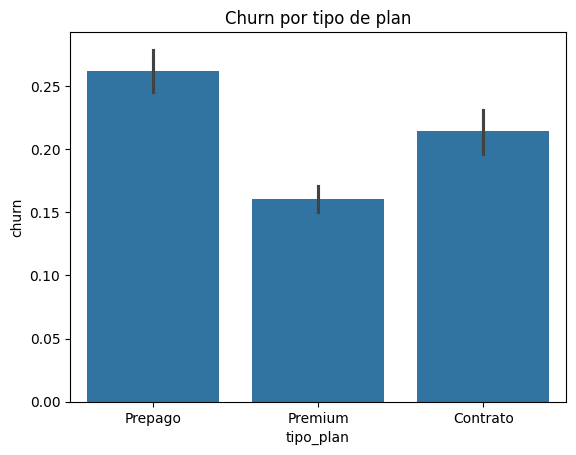

In [129]:
sns.barplot(data=df_clientes, x="tipo_plan", y="churn")
plt.title("Churn por tipo de plan")
plt.show()

Los clientes con descuento activo tienen menor churn.

In [130]:
df_clientes.groupby("tipo_zona")["churn"].mean().sort_values(ascending=False)

tipo_zona
rural             0.329759
suburbana         0.213522
urbana_premium    0.144705
Name: churn, dtype: float64

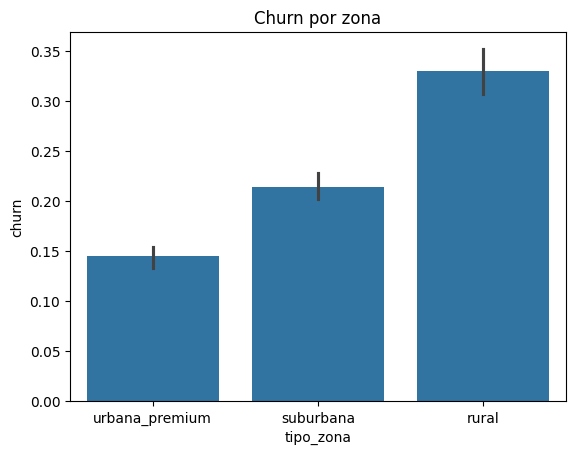

In [131]:
sns.barplot(data=df_clientes, x="tipo_zona", y="churn")
plt.title("Churn por zona")
plt.show()

Las zonas rurales presentan mayor churn.

In [132]:
df_clientes.groupby("churn")["ingreso_estimado"].mean()

churn
0    3579.574369
1    3065.636028
Name: ingreso_estimado, dtype: float64

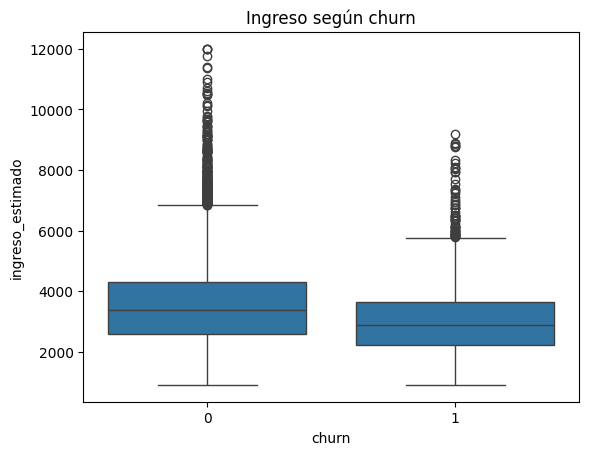

In [133]:
sns.boxplot(data=df_clientes, x="churn", y="ingreso_estimado")
plt.title("Ingreso según churn")
plt.show()

El ingreso muestra diferencias entre clientes con y sin churn.

In [134]:
df_clientes.groupby("region")["churn"].mean()
df_clientes.groupby("num_lineas")["churn"].mean()
df_clientes.groupby("edad")["churn"].mean()

edad
18.0    0.170732
19.0    0.131868
20.0    0.074468
21.0    0.210938
22.0    0.166667
          ...   
76.0    0.500000
77.0    0.666667
78.0    0.250000
79.0    0.000000
80.0    0.000000
Name: churn, Length: 64, dtype: float64

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CARGAR DATOS
# ============================================================

clientes = pd.read_csv("data/processed/df_clientes.csv")
churn = pd.read_csv("data/processed/df_churn.csv")

clientes.columns = clientes.columns.str.strip()
churn.columns = churn.columns.str.strip()

clientes["cliente_id"] = clientes["cliente_id"].astype(str)
churn["cliente_id"] = churn["cliente_id"].astype(str)

# Si fecha existe, la dejamos bien
if "fecha" in churn.columns:
    churn["fecha"] = pd.to_datetime(churn["fecha"], errors="coerce")

# Merge
df = churn.merge(clientes, on="cliente_id", how="left")

# ============================================================
# ARREGLAR NOMBRE DE CHURN
# ============================================================

print("COLUMNAS DISPONIBLES:")
print(df.columns.tolist())

if "churn" not in df.columns:
    if "churn_x" in df.columns:
        df["churn"] = df["churn_x"]
    elif "churn_y" in df.columns:
        df["churn"] = df["churn_y"]
    else:
        raise ValueError("No encuentro ninguna columna churn, churn_x ni churn_y.")

# ============================================================
# COMPROBAR COLUMNAS NECESARIAS
# ============================================================

columnas_necesarias = [
    "edad",
    "ingreso_estimado",
    "antiguedad_meses",
    "num_lineas",
    "churn"
]

print("\nCOLUMNAS NECESARIAS:")
for col in columnas_necesarias:
    print(col, "✅" if col in df.columns else "❌")

df_model = df[columnas_necesarias].dropna()

print("\nShape df_model:")
print(df_model.shape)

print("\nNulos:")
print(df_model.isnull().sum())

df_model.head()

COLUMNAS DISPONIBLES:
['cliente_id', 'fecha', 'churn_x', 'zona_id', 'region', 'tipo_zona', 'poblacion_zona', 'edad', 'sexo', 'estado_civil', 'num_lineas', 'tipo_plan', 'tipo_dispositivo', 'ingreso_estimado', 'antiguedad_meses', 'descuento_activo', 'churn_y']

COLUMNAS NECESARIAS:
edad ✅
ingreso_estimado ✅
antiguedad_meses ✅
num_lineas ✅
churn ✅

Shape df_model:
(321987, 5)

Nulos:
edad                0
ingreso_estimado    0
antiguedad_meses    0
num_lineas          0
churn               0
dtype: int64


,edad,ingreso_estimado,antiguedad_meses,num_lineas,churn
0,18.0,4335.0,72.0,2,0
1,18.0,4335.0,72.0,2,0
2,18.0,4335.0,72.0,2,0
3,18.0,4335.0,72.0,2,0
4,18.0,4335.0,72.0,2,0



CHURN RATE POR GRUPO DE EDAD:
grupo_edad
Hasta 30    0.544935
31-45       0.620059
46-60       0.682783
60+         0.707719
Name: churn, dtype: float64


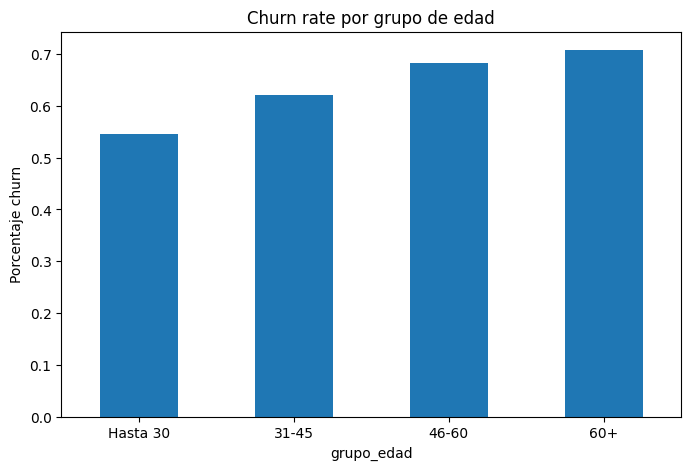

In [136]:
# ============================================================
# SEGMENTACIÓN Y MODELADO - ENFOQUE A
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

variables_base = [
    "edad",
    "ingreso_estimado",
    "antiguedad_meses",
    "num_lineas"
]

# ============================================================
# 1. CHURN POR GRUPO DE EDAD
# ============================================================

df_model["grupo_edad"] = pd.cut(
    df_model["edad"],
    bins=[0, 30, 45, 60, 100],
    labels=["Hasta 30", "31-45", "46-60", "60+"]
)

tabla_edad = df_model.groupby("grupo_edad")["churn"].mean() * 100

print("\nCHURN RATE POR GRUPO DE EDAD:")
print(tabla_edad)

plt.figure(figsize=(8,5))
tabla_edad.plot(kind="bar")
plt.title("Churn rate por grupo de edad")
plt.ylabel("Porcentaje churn")
plt.xticks(rotation=0)
plt.show()


CHURN RATE POR SEGMENTO:
segmento_cliente
Cliente estándar      0.689803
Joven reciente        0.953344
Premium fidelizado    0.312313
Name: churn, dtype: float64


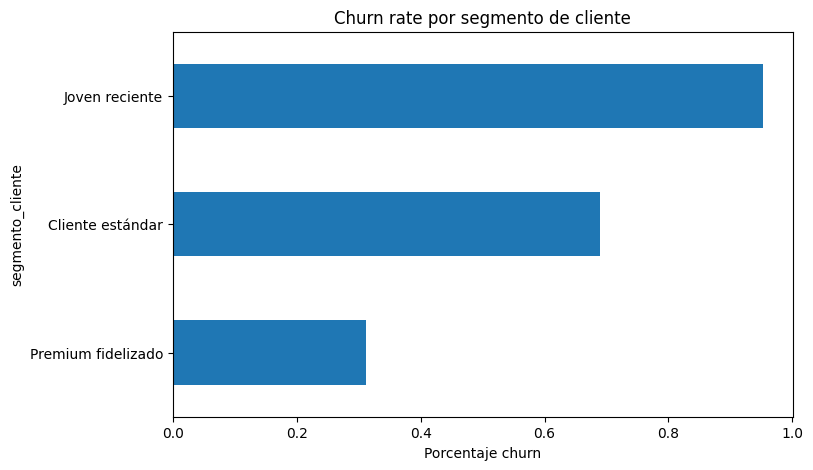

In [137]:
# ============================================================
# 2. SEGMENTACIÓN DE CLIENTES
# ============================================================

df_model["segmento_cliente"] = np.where(
    (df_model["ingreso_estimado"] >= 4000) &
    (df_model["antiguedad_meses"] >= 24),
    "Premium fidelizado",
    np.where(
        (df_model["edad"] < 30) &
        (df_model["antiguedad_meses"] < 12),
        "Joven reciente",
        "Cliente estándar"
    )
)

tabla_segmentos = df_model.groupby("segmento_cliente")["churn"].mean() * 100

print("\nCHURN RATE POR SEGMENTO:")
print(tabla_segmentos)

plt.figure(figsize=(8,5))
tabla_segmentos.sort_values().plot(kind="barh")
plt.title("Churn rate por segmento de cliente")
plt.xlabel("Porcentaje churn")
plt.show()


PERFIL DE CLUSTERS:
              edad  ingreso_estimado  antiguedad_meses  num_lineas     churn
cluster                                                                     
0        45.514184       3380.171581         28.456935    3.628572  0.006910
1        43.189940       2767.858034         26.454648    1.545096  0.008065
2        38.342438       3431.771682         69.907550    2.174091  0.003596
3        29.548194       4661.141489         28.103646    2.303661  0.004781


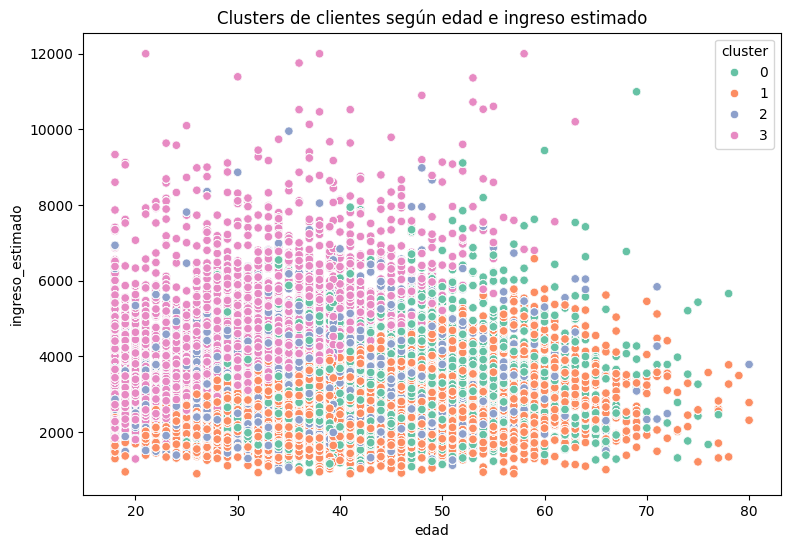

In [138]:
# ============================================================
# 3. CLUSTERING
# ============================================================

X_cluster = df_model[variables_base]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_model["cluster"] = kmeans.fit_predict(X_scaled)

perfil_clusters = df_model.groupby("cluster")[variables_base + ["churn"]].mean()

print("\nPERFIL DE CLUSTERS:")
print(perfil_clusters)

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df_model,
    x="edad",
    y="ingreso_estimado",
    hue="cluster",
    palette="Set2"
)
plt.title("Clusters de clientes según edad e ingreso estimado")
plt.show()

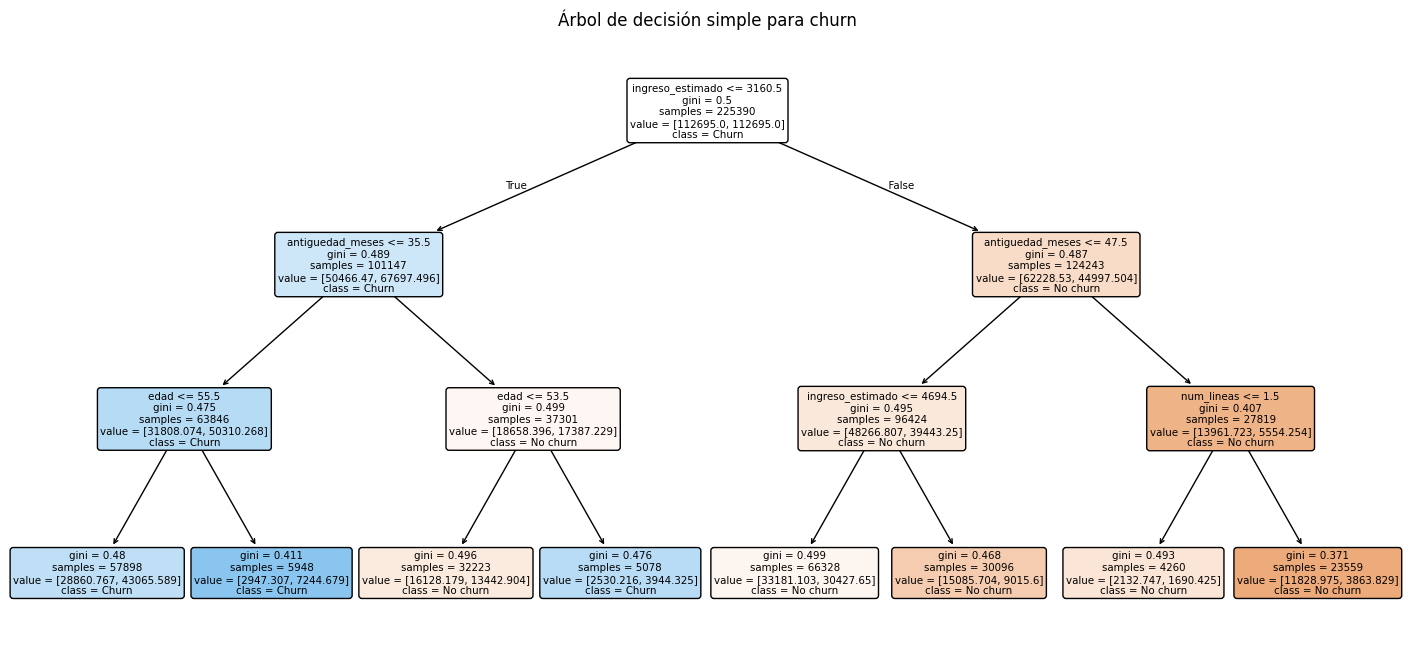


ACCURACY:
0.5379877221859892

MATRIZ DE CONFUSIÓN:
[[51564 44433]
 [  196   404]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.54      0.70     95997
           1       0.01      0.67      0.02       600

    accuracy                           0.54     96597
   macro avg       0.50      0.61      0.36     96597
weighted avg       0.99      0.54      0.69     96597


COEFICIENTES REGRESIÓN LOGÍSTICA:
           variable  coeficiente
3        num_lineas     0.010646
0              edad     0.007047
1  ingreso_estimado    -0.000251
2  antiguedad_meses    -0.013931


In [139]:
# ============================================================
# 4. ÁRBOL DE DECISIÓN
# ============================================================

X = df_model[variables_base]
y = df_model["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

arbol = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    class_weight="balanced"
)

arbol.fit(X_train, y_train)

plt.figure(figsize=(18,8))
plot_tree(
    arbol,
    feature_names=variables_base,
    class_names=["No churn", "Churn"],
    filled=True,
    rounded=True
)
plt.title("Árbol de decisión simple para churn")
plt.show()

# ============================================================
# 5. REGRESIÓN LOGÍSTICA
# ============================================================

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("\nACCURACY:")
print(accuracy_score(y_test, y_pred))

print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

coeficientes = pd.DataFrame({
    "variable": variables_base,
    "coeficiente": log_model.coef_[0]
}).sort_values(by="coeficiente", ascending=False)

print("\nCOEFICIENTES REGRESIÓN LOGÍSTICA:")
print(coeficientes)

El análisis muestra que el churn no se distribuye de manera uniforme entre los clientes. Se observa que los clientes con menor antigüedad, aquellos con planes prepago, los que residen en zonas rurales y los que no tienen descuentos activos presentan una mayor probabilidad de abandono. Estos resultados permiten identificar segmentos de alto riesgo sobre los que se deberían enfocar estrategias de retención.

In [140]:
df_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        10000 non-null  str    
 1   zona_id           10000 non-null  str    
 2   region            10000 non-null  str    
 3   tipo_zona         10000 non-null  str    
 4   poblacion_zona    10000 non-null  int64  
 5   edad              10000 non-null  float64
 6   sexo              10000 non-null  str    
 7   estado_civil      10000 non-null  str    
 8   num_lineas        10000 non-null  int64  
 9   tipo_plan         10000 non-null  str    
 10  tipo_dispositivo  10000 non-null  str    
 11  ingreso_estimado  10000 non-null  float64
 12  antiguedad_meses  10000 non-null  float64
 13  descuento_activo  10000 non-null  int64  
 14  churn             10000 non-null  int64  
dtypes: float64(3), int64(4), str(8)
memory usage: 1.1 MB


In [141]:
df_clientes.to_csv("data/processed/df_clientes.csv", index=False)